# LAB-D3-01: Find the Data Leak - Instructor Solution

> **Instructor only.** This notebook contains completed responses and teaching notes. Do not distribute it with participant materials.

**Purpose:** Audit suspiciously strong validation evidence, identify two independent leak paths, and rebuild a trustworthy data pipeline.

**Objectives:** `OBJ-D3-02`; reinforces `OBJ-D2-08`  
**Estimated duration:** 45 minutes live; completed CPU execution under 30 seconds  
**Prerequisites:** [LESSON-D3-02](../../day-3/student-guide/day-3-student-guide.md#lesson-d3-02---real-world-data-pipelines-and-leakage), [ACT-D3-02](../../day-3/challenges/day-3-challenges.md#act-d3-02---leakage-accusation-chain-of-custody), and Day 2's training/validation distinction  
**Environment:** CPU; NumPy, matplotlib, scikit-learn; generated records; no files, cache, network, or accelerator

Workflow: **Observe report -> Inspect provenance -> Predict -> Run leaky path -> Diagnose -> Repair -> Compare -> Explain**.

## Instructor Briefing

**What and why:** The decisive defects are different: `case_resolution_code` is illegal because of *when it exists*, while the fitted scaler crosses the split boundary because of *which rows own learned state*. Removing both turns a spectacular but invalid score into useful evidence.

**Expected clean-run evidence:** leaky ROC AUC about `0.996`; valid validation ROC AUC about `0.831` and within `0.78-0.90`; split sizes `3000/1000/1000`; training scaled means numerically zero while validation means are not exactly zero; optional batch shapes `(64,8)` and `(64,)`. The first plot should make the post-outcome feature conspicuous. The comparison plot should show a lower AUC and less-perfect valid confusion matrix.

**Hint ladder:**
1. Ask, "Could this field exist at scoring time?"
2. Ask learners to mark the line where each transform learns parameters.
3. Have them trace whether any validation row can affect a fitted mean or standard deviation.
4. If split math stalls, first reserve `40%`, then divide that remainder equally into validation and test with stratification at both stages.

**Likely misconceptions:** high AUC alone proves leakage; weak correlation makes a feature legal; applying a training-fitted transform to validation is leakage; scaling before the split is harmless because labels are absent; a lower repaired score means the repair made the model worse.

**Discussion triggers:** Which evidence is statistical and which is provenance evidence? Why does the post-outcome field dominate even though both defects violate the contract? What deployment risks remain after this repair?

**Troubleshooting and live recovery:** Restore `SEED=3101`, exactly eight intake features, and the supplied proxy construction if bands drift. If time is short, run through the valid AUC cell and discuss the supplied comparison plot. A manual two-stage stratified split or an equivalent helper is acceptable; a train-fitted `ColumnTransformer` is also valid if it preserves feature ownership. CPU is the required path, and a GPU would not materially help this tiny logistic-regression run.

In [1]:
import platform
import time

import matplotlib.pyplot as plt
import numpy as np
import sklearn
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

SEED = 3101
plt.rcParams.update({"figure.figsize": (8, 4.5), "axes.grid": True, "grid.alpha": 0.2})
print(f"Python {platform.python_version()} | NumPy {np.__version__} | scikit-learn {sklearn.__version__}")
print("Required device: CPU | Data: generated locally | Runtime target: under 30 seconds")

Python 3.11.8 | NumPy 2.2.4 | scikit-learn 1.9.0
Required device: CPU | Data: generated locally | Runtime target: under 30 seconds


## Observe: Provenance Before Code

A case-triage team reports validation ROC AUC above `0.99`. Audit availability before inspecting implementation.

| Field | Created | Available when a new case is scored? | Intended meaning |
|---|---|---:|---|
| `intake_severity` | intake | yes | initial severity |
| `prior_contacts` | intake | yes | prior contact count |
| `account_age_days` | intake | yes | account tenure |
| `queue_pressure` | intake | yes | queue load |
| `region_risk` | intake | yes | historical regional rate |
| `signal_5` to `signal_8` | intake | yes | anonymized intake measurements |
| `case_resolution_code` | after closure | **no** | final workflow disposition |
| `needs_escalation` | after review | target | outcome to predict |

High AUC is a clue, not proof of leakage. Name evidence that could distinguish real signal from invalid provenance.

In [2]:
audit_predictions = {
    "is_auc_plausible": "Possible but implausible enough to audit before trusting it.",
    "top_two_hypotheses": "A post-outcome target proxy or genuine strong intake signal.",
    "first_discriminating_check": "Remove the post-closure field and rerun the same model on a valid split.",
    "feature_to_audit_first_and_why": "case_resolution_code, because it is created after the prediction decision.",
    "which_preprocessing_state_may_use_validation": "Any scaler means and variances fitted before splitting.",
}
assert all(value.strip() for value in audit_predictions.values()), (
    "Prediction gate: complete the provenance audit before generating or fitting anything."
)

## Generate the Case Records

The eight intake fields come from `make_classification`. The post-outcome field is generated afterward from the target with a small recording error. This construction is intentionally invalid for prediction-time use.

In [3]:
started = time.perf_counter()
X_intake, y = make_classification(
    n_samples=5000,
    n_features=8,
    n_informative=5,
    n_redundant=1,
    n_clusters_per_class=2,
    class_sep=0.95,
    flip_y=0.06,
    weights=[0.62, 0.38],
    random_state=SEED,
)
feature_names = [
    "intake_severity", "prior_contacts", "account_age_days", "queue_pressure",
    "region_risk", "signal_6", "signal_7", "signal_8",
]
rng = np.random.default_rng(SEED)
recorded_outcome = np.where(rng.random(len(y)) < 0.01, 1 - y, y)
case_resolution_code = recorded_outcome + rng.normal(0.0, 0.02, size=len(y))
X_leaky = np.column_stack([X_intake, case_resolution_code])
leaky_feature_names = feature_names + ["case_resolution_code"]
assert X_intake.shape == (5000, 8) and X_leaky.shape == (5000, 9)
print(f"Records: {X_leaky.shape}; escalation rate: {y.mean():.3f}")

Records: (5000, 9); escalation rate: 0.388


## Deliberate Failure: The Suspicious Pipeline

The code below makes two invalid choices: it includes a post-outcome field and fits the scaler before the split. Predict the score band and which defect is likely to dominate before running it.

In [4]:
leaky_run_predictions = {
    "auc_band": "0.99-1.00",
    "dominant_leak": "The post-outcome case_resolution_code should dominate.",
    "why_fit_before_split_is_invalid_even_if_effect_is_small": "Validation values influence fitted scaling state, violating held-out ownership.",
}
assert all(value.strip() for value in leaky_run_predictions.values())

leaky_scaler = StandardScaler().fit(X_leaky)  # Deliberate failure: all records influenced fitted state.
X_scaled_before_split = leaky_scaler.transform(X_leaky)
X_train_leaky, X_val_leaky, y_train_leaky, y_val_leaky = train_test_split(
    X_scaled_before_split,
    y,
    test_size=0.20,
    random_state=SEED,
    stratify=y,
)
leaky_model = LogisticRegression(max_iter=1000, random_state=SEED)
leaky_model.fit(X_train_leaky, y_train_leaky)
leaky_probabilities = leaky_model.predict_proba(X_val_leaky)[:, 1]
leaky_auc = roc_auc_score(y_val_leaky, leaky_probabilities)
print(f"Suspicious validation ROC AUC: {leaky_auc:.4f}")
assert 0.99 <= leaky_auc <= 1.00

Suspicious validation ROC AUC: 0.9960


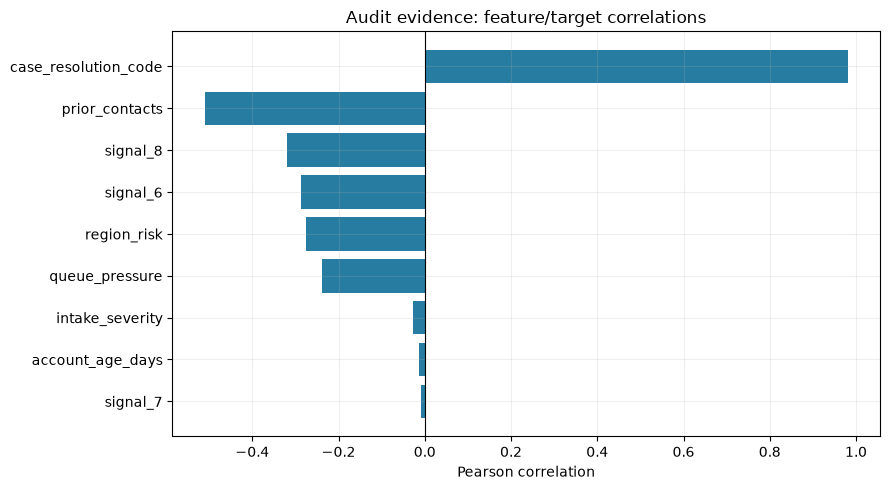

In [5]:
correlations = np.array([np.corrcoef(X_leaky[:, index], y)[0, 1] for index in range(X_leaky.shape[1])])
order = np.argsort(np.abs(correlations))
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(np.array(leaky_feature_names)[order], correlations[order], color="#277da1")
ax.axvline(0.0, color="black", linewidth=0.8)
ax.set(title="Audit evidence: feature/target correlations", xlabel="Pearson correlation")
plt.tight_layout()
plt.show()

## Diagnose Before Repair

Cite provenance and code evidence separately. A correlation can prioritize an audit, but timing determines whether a field is legal at prediction time.

In [6]:
leak_diagnosis = {
    "post_outcome_evidence": "Provenance says case_resolution_code is created after closure, and its correlation is near the target.",
    "split_boundary_evidence": "StandardScaler.fit receives all records before train_test_split.",
    "why_high_auc_alone_is_not_proof": "Strong legal predictors or an evaluation bug can also produce a high score; provenance distinguishes them.",
    "repair_order": "Quarantine unavailable fields, stratified split, fit preprocessing and model on train, compare on validation, then evaluate test once.",
}
assert all(value.strip() for value in leak_diagnosis.values())

## Modify: Build a Valid Pipeline

Complete two focused functions:

1. `make_valid_splits` must remove `case_resolution_code` before a seeded, stratified `60/20/20` train/validation/test split.
2. `fit_valid_pipeline` must fit a `Pipeline(StandardScaler(), LogisticRegression())` on training data only.

Validation may measure the fitted pipeline. Test remains untouched until the validation comparison is complete.

In [7]:
def make_valid_splits(X_intake, y, seed):
    X_train, X_remaining, y_train, y_remaining = train_test_split(
        X_intake, y, test_size=0.40, random_state=seed, stratify=y
    )
    X_val, X_test, y_val, y_test = train_test_split(
        X_remaining, y_remaining, test_size=0.50, random_state=seed, stratify=y_remaining
    )
    return X_train, X_val, X_test, y_train, y_val, y_test

def fit_valid_pipeline(X_train, y_train, seed):
    pipeline = Pipeline([
        ("scale", StandardScaler()),
        ("model", LogisticRegression(max_iter=1000, random_state=seed)),
    ])
    return pipeline.fit(X_train, y_train)

X_train, X_val, X_test, y_train, y_val, y_test = make_valid_splits(X_intake, y, SEED)
valid_pipeline = fit_valid_pipeline(X_train, y_train, SEED)
assert X_train.shape == (3000, 8) and X_val.shape == X_test.shape == (1000, 8)
assert abs(y_train.mean() - y_val.mean()) < 0.01
assert abs(y_train.mean() - y_test.mean()) < 0.01
assert "case_resolution_code" not in feature_names

In [8]:
valid_probabilities = valid_pipeline.predict_proba(X_val)[:, 1]
valid_auc = roc_auc_score(y_val, valid_probabilities)
train_scaled = valid_pipeline.named_steps["scale"].transform(X_train)
val_scaled = valid_pipeline.named_steps["scale"].transform(X_val)
print(f"Valid validation ROC AUC: {valid_auc:.4f}")
print("Scaled training means:", np.round(train_scaled.mean(axis=0), 6))
print("Scaled validation means:", np.round(val_scaled.mean(axis=0), 3))
assert 0.78 <= valid_auc <= 0.90
assert np.allclose(train_scaled.mean(axis=0), 0.0, atol=1e-10)
assert not np.allclose(val_scaled.mean(axis=0), 0.0, atol=1e-3)

Valid validation ROC AUC: 0.8310
Scaled training means: [-0.  0. -0. -0. -0.  0. -0. -0.]
Scaled validation means: [ 0.003  0.005  0.002  0.037 -0.021 -0.025  0.025 -0.055]


## Inspect: Lower Score, Stronger Evidence

Compare ROC AUC and confusion matrices under the same threshold. The score drop is a validity gain. It does not prove that every remaining deployment risk is solved.

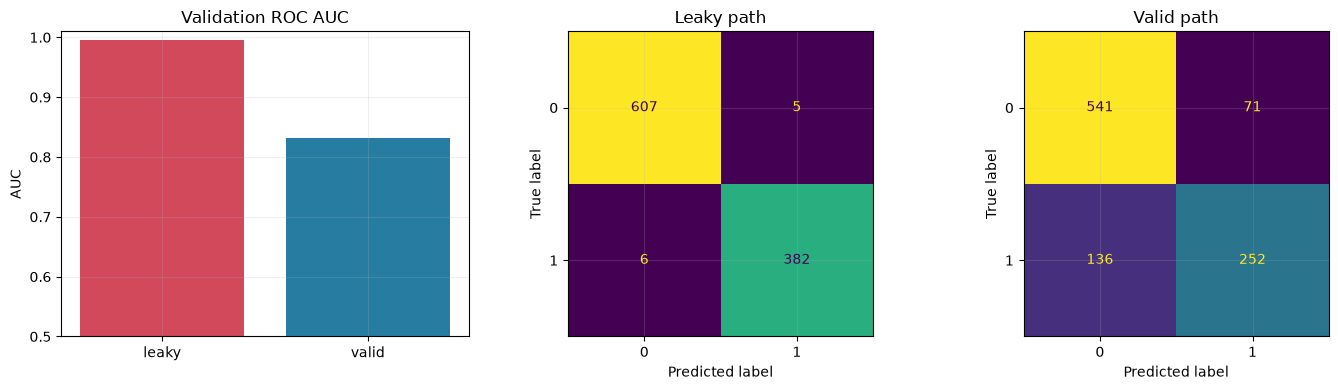

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].bar(["leaky", "valid"], [leaky_auc, valid_auc], color=["#d1495b", "#277da1"])
axes[0].set(title="Validation ROC AUC", ylabel="AUC", ylim=(0.5, 1.01))
ConfusionMatrixDisplay.from_predictions(y_val_leaky, leaky_probabilities >= 0.5, ax=axes[1], colorbar=False)
axes[1].set_title("Leaky path")
ConfusionMatrixDisplay.from_predictions(y_val, valid_probabilities >= 0.5, ax=axes[2], colorbar=False)
axes[2].set_title("Valid path")
plt.tight_layout()
plt.show()

## Optional Extension: Loader Shape and Shuffle Policy

Set `RUN_OPTIONAL_LOADER_CHECK = True` to wrap the valid training split in a PyTorch `DataLoader`. Training may shuffle; validation/test should not. This extension does not affect the core checkpoint.

In [10]:
RUN_OPTIONAL_LOADER_CHECK = True
optional_loader_interpretation = "The leading dimension is the 64-example batch; only training shuffles to vary batch order while evaluation order stays stable."
if not RUN_OPTIONAL_LOADER_CHECK:
    print("Optional loader check skipped. Core checkpoint is unaffected.")
else:
    import torch
    from torch.utils.data import DataLoader, TensorDataset

    train_dataset = TensorDataset(torch.tensor(X_train, dtype=torch.float32), torch.tensor(y_train, dtype=torch.long))
    train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, generator=torch.Generator().manual_seed(SEED))
    X_batch, y_batch = next(iter(train_loader))
    assert X_batch.shape == (64, 8) and y_batch.shape == (64,)
    print("Optional first batch:", X_batch.shape, y_batch.shape)
    assert optional_loader_interpretation.strip(), "Explain the batch dimension and why only training shuffles."

Optional first batch: torch.Size([64, 8]) torch.Size([64])


## Challenge: Audit One More Feature

A proposed `hours_until_resolution` field is measured after closure. Decide whether to include it, name the evidence that controls the decision, and identify one legal alternative available at intake. Do not use model score as the only argument.

In [11]:
challenge_response = {
    "include_or_exclude": "Exclude hours_until_resolution.",
    "controlling_provenance_evidence": "It is measured only after closure and is unavailable when scoring a new case.",
    "legal_alternative": "Use elapsed hours since intake at prediction time.",
    "remaining_validity_risk": "Entity duplication or future distribution shift could still invalidate the estimate.",
}
assert all(value.strip() for value in challenge_response.values())

## Reflect and Checkpoint

Explain why fitting a transform means learning state, why applying the fitted training transform to validation is allowed, and why the test split stays outside iterative decisions.

In [12]:
reflection = {
    "what_crossed_the_split_boundary": "Post-outcome target information and validation-derived scaler statistics entered fitting.",
    "fit_vs_apply": "Fit learns means and variances from training; apply uses that fixed state without learning from validation.",
    "why_lower_auc_is_more_trustworthy": "It measures only prediction-time features under held-out preprocessing ownership.",
    "test_set_role": "It provides one final estimate after validation-driven choices are fixed.",
}
assert all(value.strip() for value in reflection.values())
assert 0.99 <= leaky_auc <= 1.00
assert 0.78 <= valid_auc <= 0.90
assert X_train.shape[1] == 8 and X_train_leaky.shape[1] == 9
assert time.perf_counter() - started < 30.0
print("LAB-D3-01 checkpoint passed: two leak paths diagnosed, valid split order restored, proxy removed, and honest evidence compared.")

LAB-D3-01 checkpoint passed: two leak paths diagnosed, valid split order restored, proxy removed, and honest evidence compared.


## Takeaways

- Availability time is as important as correlation when auditing features.
- Split before fitting learned preprocessing state.
- Fit transforms on training data, then apply the fixed transform to validation/test.
- A lower valid score is more useful than a near-perfect contaminated score.
- High performance is a reason to investigate, not proof of leakage by itself.

## Troubleshooting

| Symptom | Likely cause | Recovery |
|---|---|---|
| Leaky AUC is below `0.99` | Seed, proxy construction, or split changed | Restore supplied generator and seed |
| Valid AUC is outside `0.78-0.90` | Proxy remained or generator settings changed | Confirm exactly eight intake features |
| Validation scaled means are all zero | Scaler was fitted separately on validation | Use the scaler already fitted inside the training pipeline |
| Class proportions drift | Split omitted `stratify=y` | Add stratification at both split stages |
| Runtime exceeds 30 seconds | Dataset/model size was increased | Restore 5,000 records and one logistic model per path |

## Continue

Return to the [LAB-D3-01 debrief](../../day-3/student-guide/day-3-student-guide.md#lab-d3-01-debrief---a-lower-honest-score). Review [LESSON-D3-02](../../day-3/student-guide/day-3-student-guide.md#lesson-d3-02---real-world-data-pipelines-and-leakage) and [ACT-D3-02](../../day-3/challenges/day-3-challenges.md#act-d3-02---leakage-accusation-chain-of-custody) as needed.